In [1]:
import matplotlib.pyplot as plt
from astropy.io import fits
import numpy as np

In [16]:
# 3.1 Read FITS Files
# 3.1.3
fits_files = ['M13_0001.fits', 'M13_0002.fits', 'M13_0003.fits', 'M13_0004.fits', 'M13_0005.fits']
full_data = []
for file in fits_files:
    with fits.open(file) as hdul:
        header = hdul[0].header
        data = hdul[0].data
        full_data.append(data)

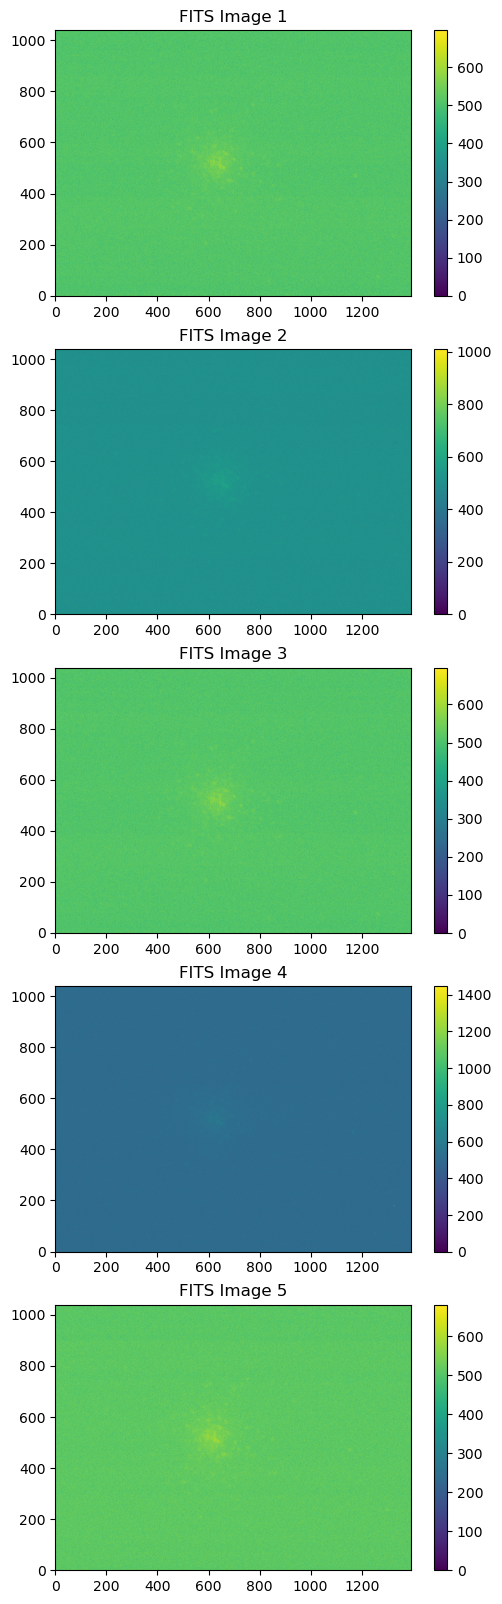

In [49]:
# 3.2 Plot Images
# 3.2.1
fig, ax = plt.subplots(5, 1, figsize=(6,20))
for i, data in enumerate(full_data):            # i is the axis number
    image = ax[i].imshow(data, origin='lower')
    ax[i].set_title(f"FITS Image {i+1}")
    plt.colorbar(image)

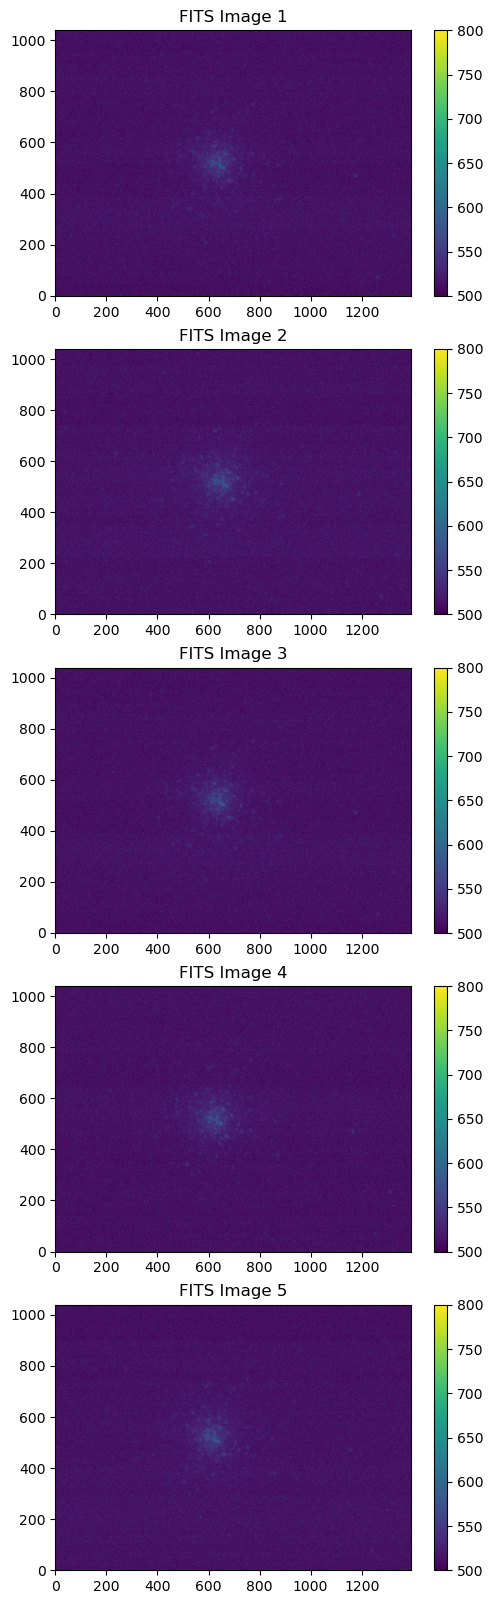

In [75]:
# 3.2.2
fig, ax = plt.subplots(5, 1, figsize=(6,20))
for i, data in enumerate(full_data):            # i is the axis number
    image = ax[i].imshow(data, origin='lower', vmin=500, vmax=800)
    ax[i].set_title(f"FITS Image {i+1}")
    plt.colorbar(image)

# Each fits file is the same image with different quality

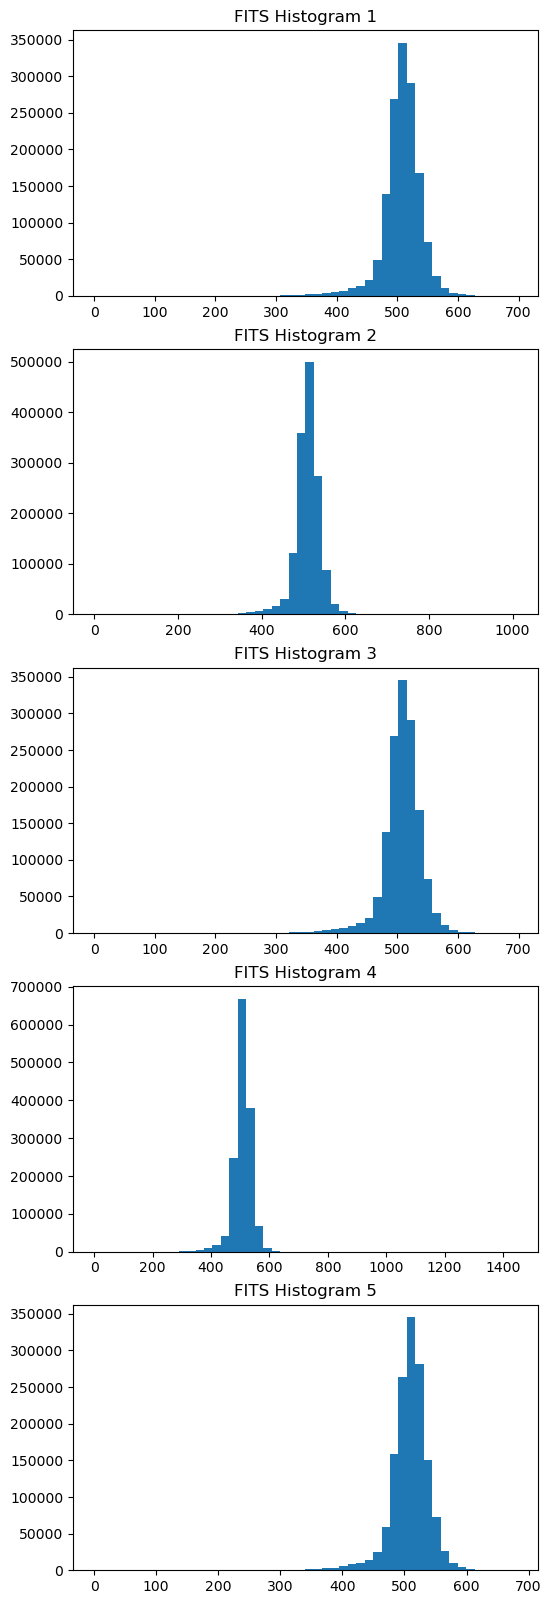

In [76]:
# 3.3 Plot Histograms
# 3.3.1
fig, ax = plt.subplots(5, 1, figsize=(6,20))
for i, data in enumerate(full_data):
    ax[i].hist(data.ravel(), bins = 50)
    ax[i].set_title(f"FITS Histogram {i+1}")


In [80]:
# 3.3.2
# a. the x axis is the pixel brightness and the y axis 
# is the number of pixels with that brightness

# b. the number of bars

# c. around 500

# d. a range of about 200

# e. 
# Histogram 1 Mean: 508.0498729000884
# Histogram 1 Median: 510.0
# Histogram 2 Mean: 509.7460150033157
# Histogram 2 Median: 511.0 
# Histogram 3 Mean: 508.0498729000884
# Histogram 3 Median: 510.0
# Histogram 4 Mean: 507.90583554376656
# Histogram 4 Median: 509.0
# Histogram 5 Mean: 508.7919920148099
# Histogram 5 Median: 510.0
for data in full_data:
    mean_val = np.mean(data.ravel())
    median_val = np.median(data.ravel())
    print(mean_val, median_val)

508.0498729000884 510.0
509.7460150033157 511.0
508.0498729000884 510.0
507.90583554376656 509.0
508.7919920148099 510.0


In [89]:
# 3.4 Combine and Normalize Images
# 3.4.1
combined_image = np.median(np.array(full_data), axis=0)
np.median(combined_image)
# median = 510

np.float64(510.0)

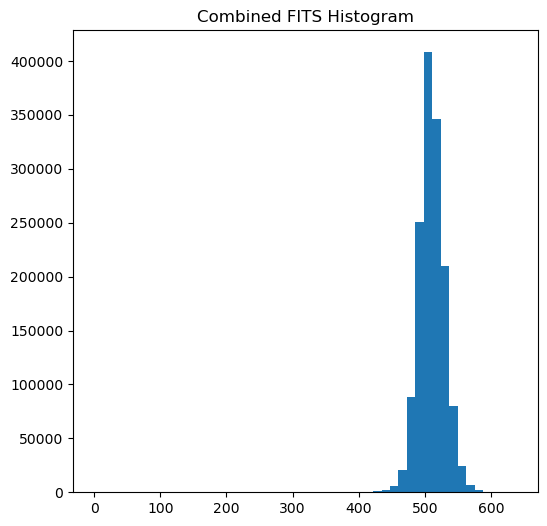

In [96]:
# 3.4.2
plt.figure(figsize=(6,6))
plt.hist(combined_image.ravel(), bins = 50)
plt.title('Combined FITS Histogram')
plt.show()

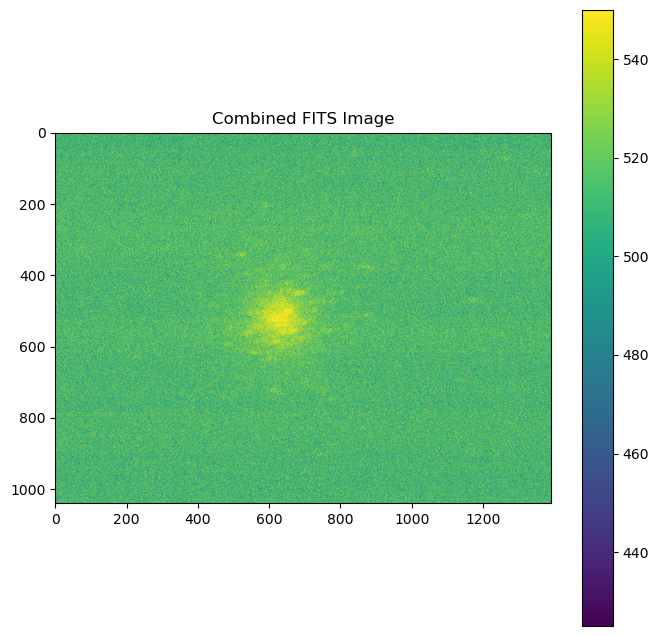

In [109]:
# 3.4.3
plt.figure(figsize=(8,8))
image = plt.imshow(combined_image, vmin = 425, vmax = 550)
plt.title('Combined FITS Image')
plt.colorbar(image)
plt.show()

In [105]:
# 3.4.4
# The image is significantly more clear

In [110]:
# 3.4.5
fits.writeto('combined.fits', combined_image, overwrite = True)

In [ ]:
# No time for bonus :(